# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [2]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

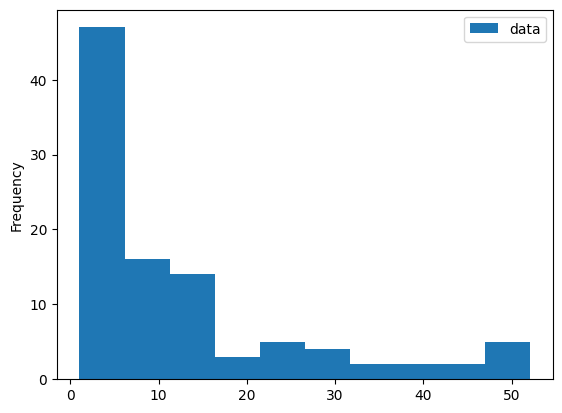

In [3]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

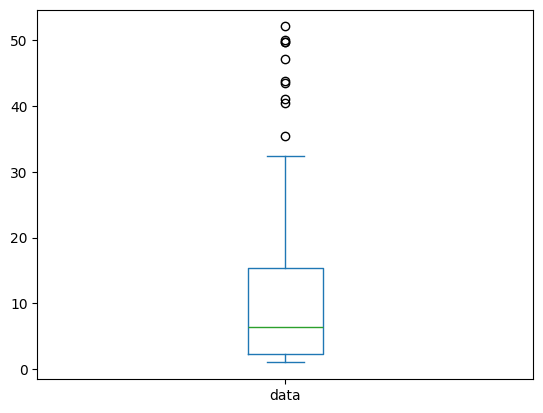

In [4]:
df.plot.box()

Histogram:
* Pros - Shows the distribution of the graph, frequency value is relevant, very obvious to understand
* Cons - Difficult to identify in terms of quantiles

Box Plot:
* Pros - Shows the statistcal values like median and percentiles, outliers are more apparent.
* Cons - Less obvious to understand, doesn't show distribution

I think the box plot does a better job of showing the compariosn between a more expensive drug so I would choose this visualization.

For formatting, giving the charts titles, and axis labels.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

### Dataset 1: Diabetes

In [5]:
diabetes_path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Path to dataset files:", diabetes_path)

Path to dataset files: /Users/ishita/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1


In [6]:
dataset_path_to_file = os.path.join(diabetes_path, "diabetes_012_health_indicators_BRFSS2015.csv")
diabetes_raw_data = pd.read_csv(dataset_path_to_file)

In [7]:
diabetes_df = diabetes_raw_data.drop_duplicates()
diabetes_df = diabetes_df[diabetes_df['BMI'] <= 60]

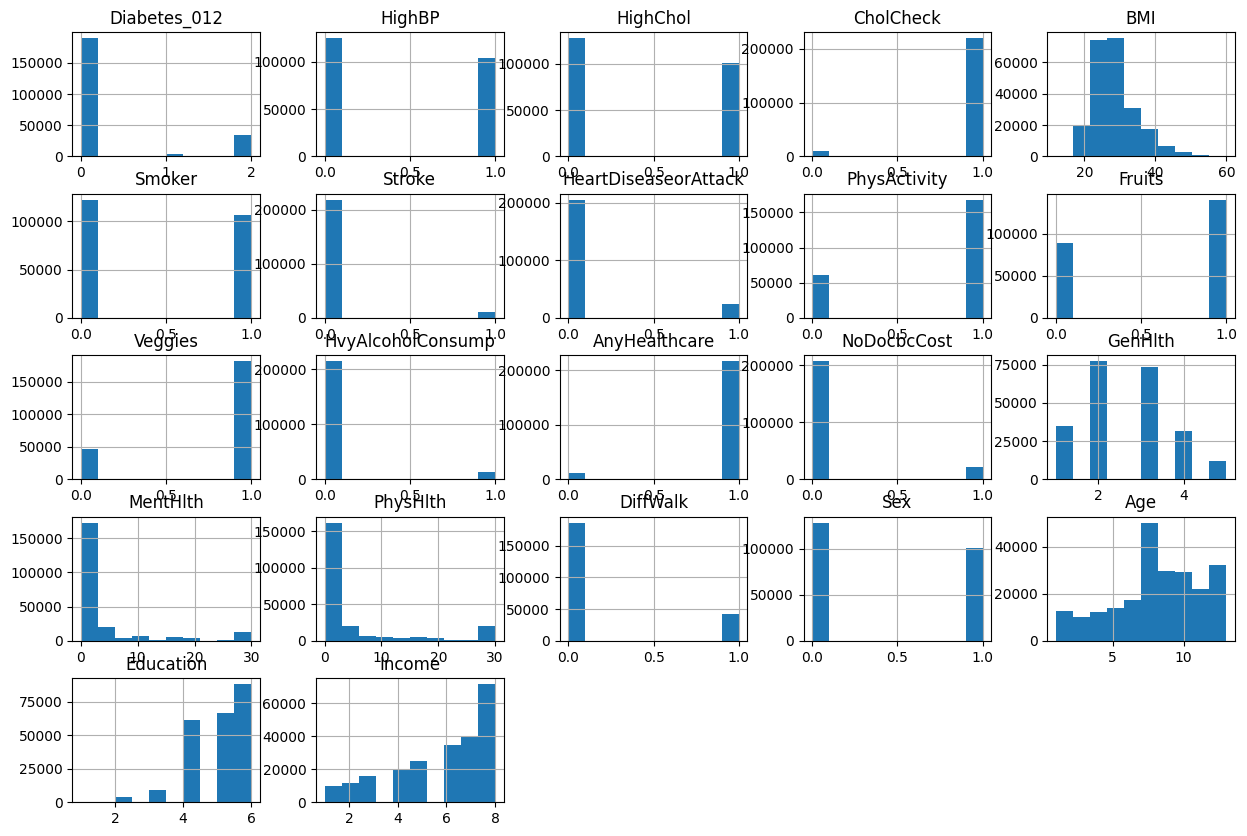

In [8]:
diabetes_df.hist(figsize=(15, 10))
plt.show()

In [9]:
numerical_columns = diabetes_df.select_dtypes(include=['float64', 'int64']).columns
numerical_columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

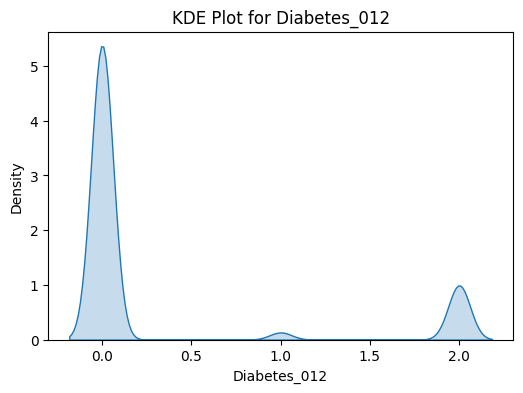

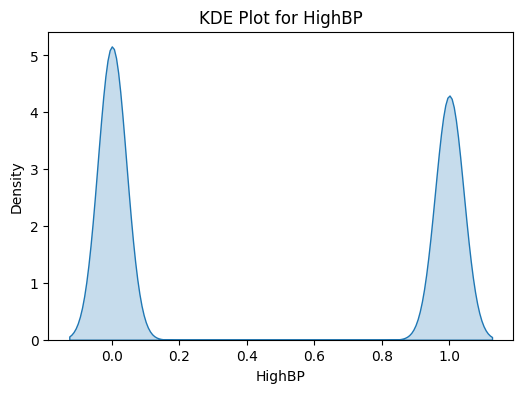

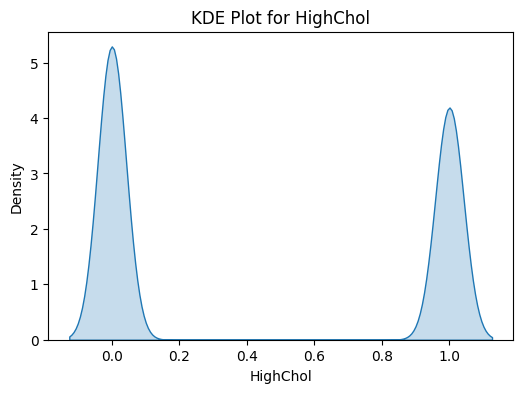

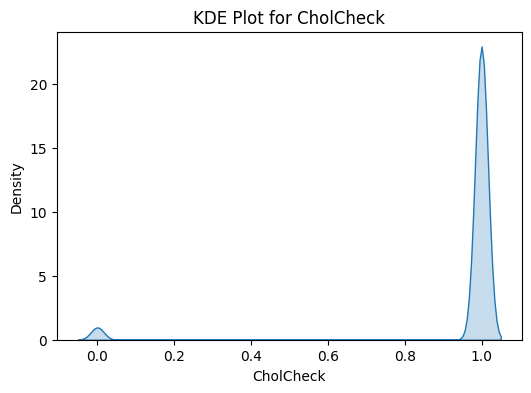

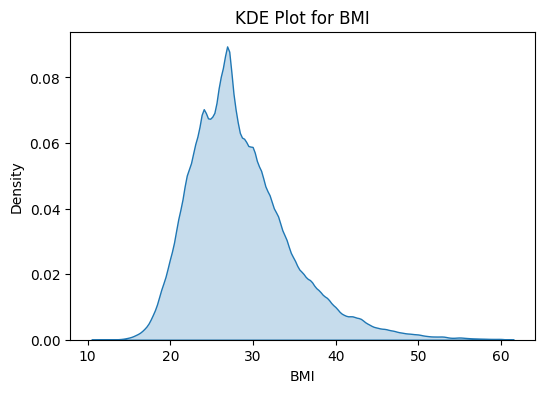

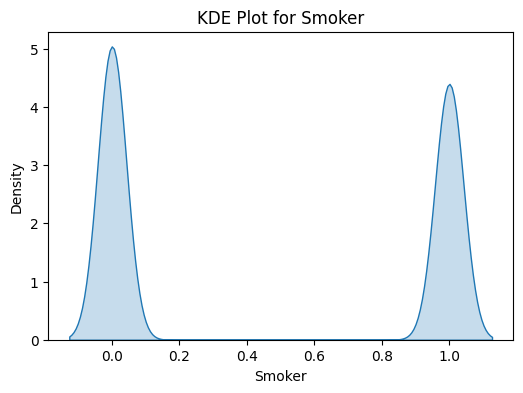

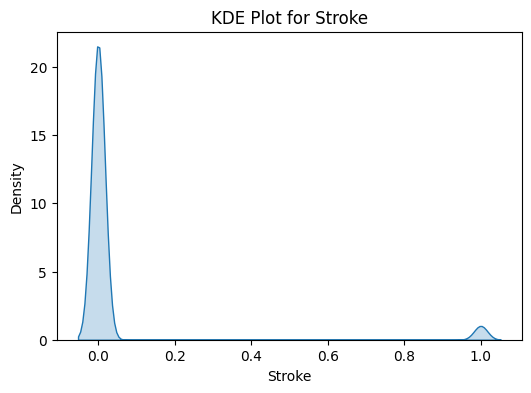

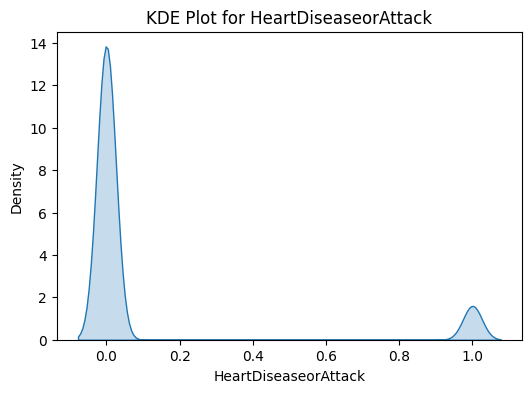

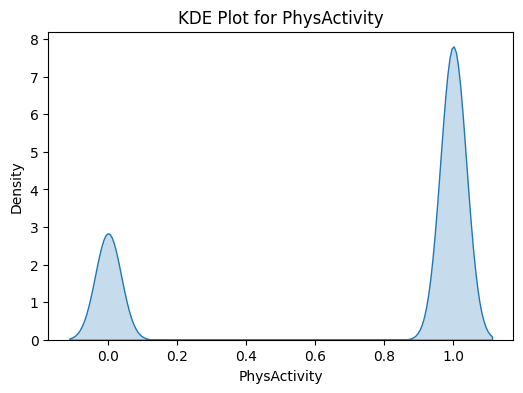

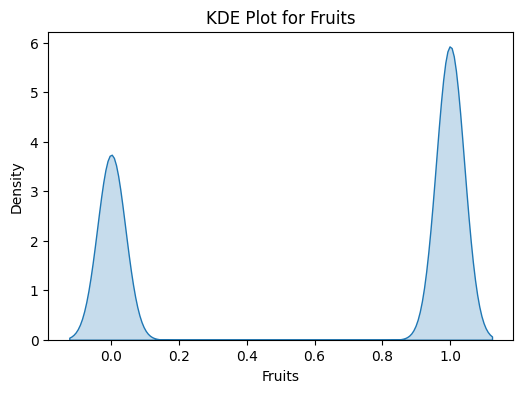

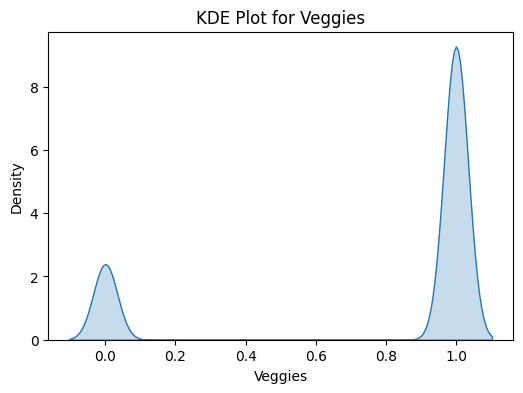

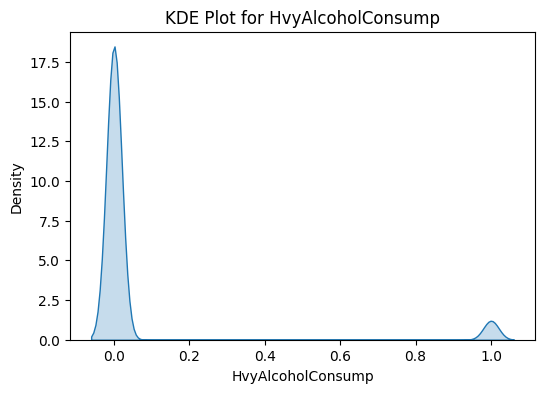

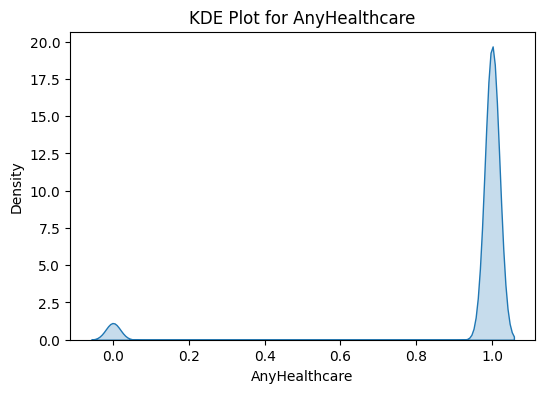

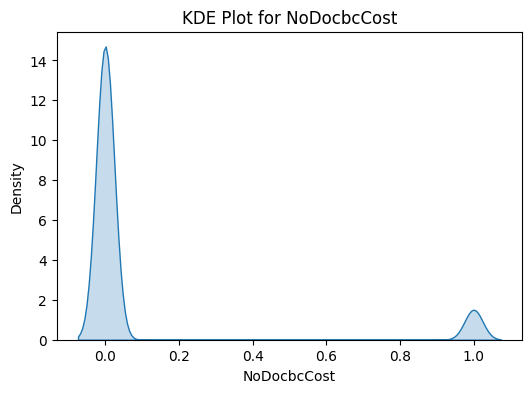

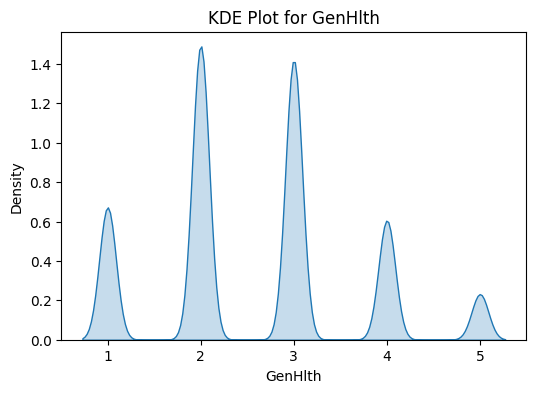

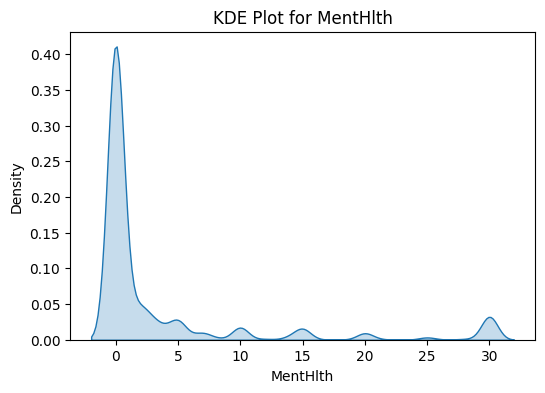

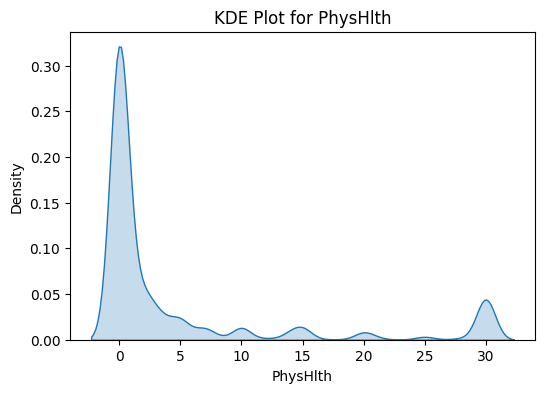

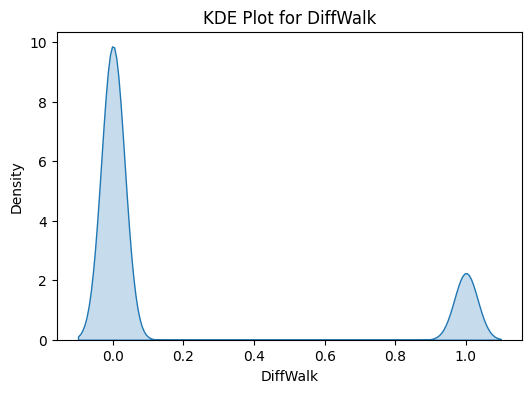

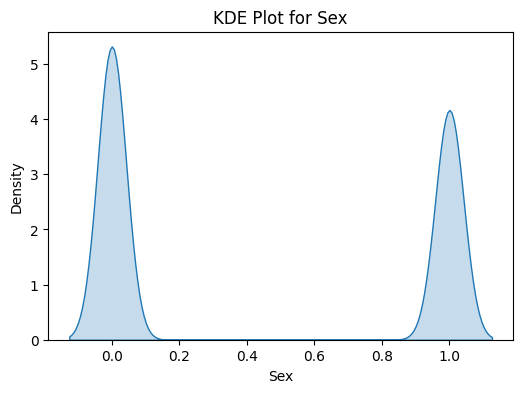

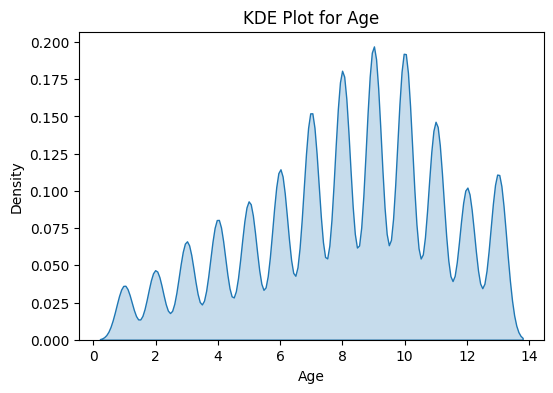

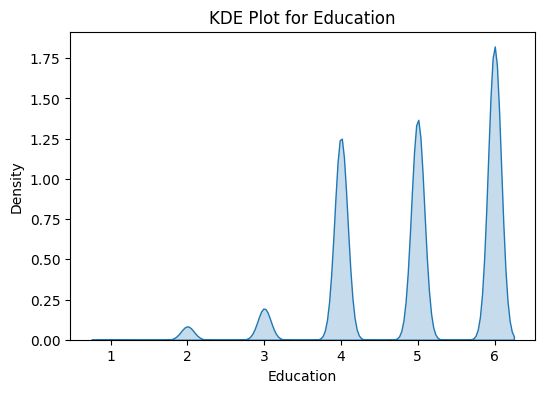

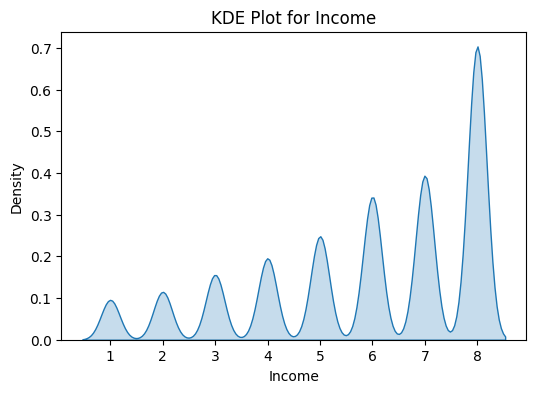

In [10]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=diabetes_df, x=col, fill=True)
    plt.title(f'KDE Plot for {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

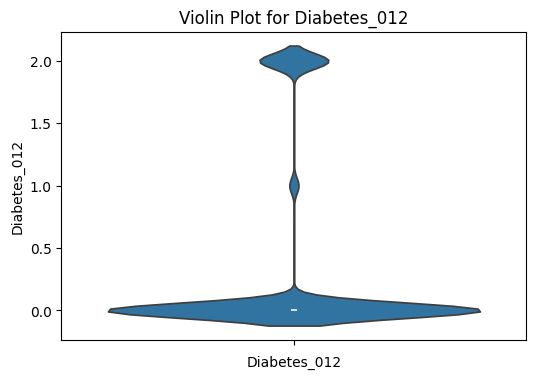

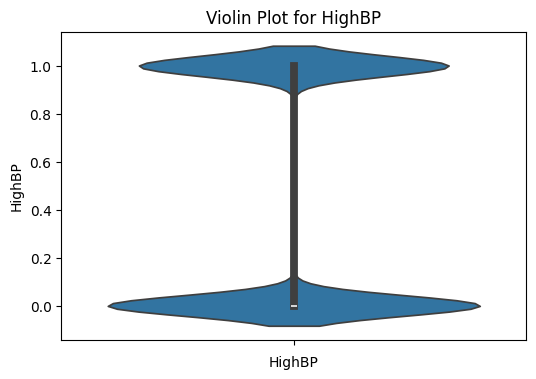

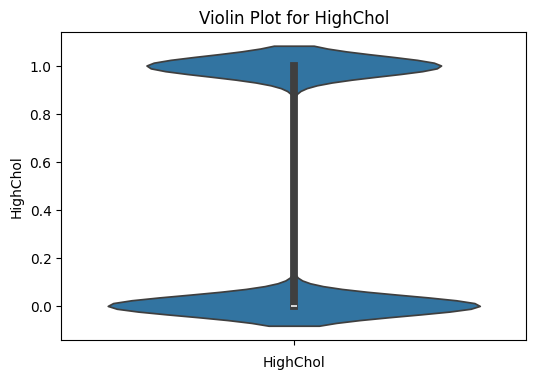

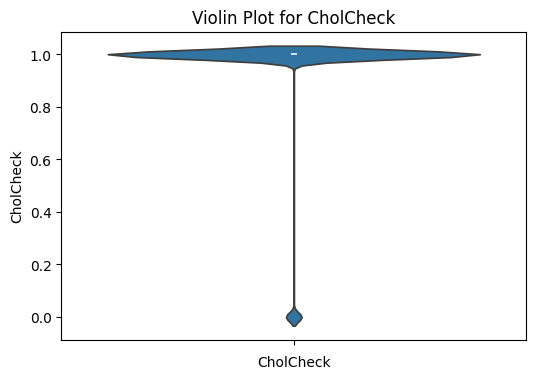

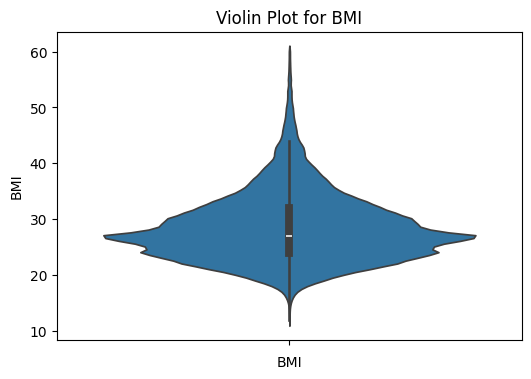

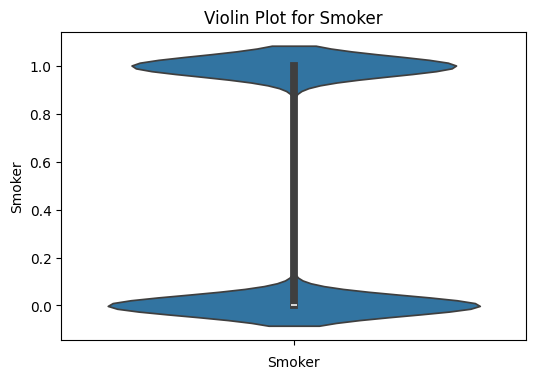

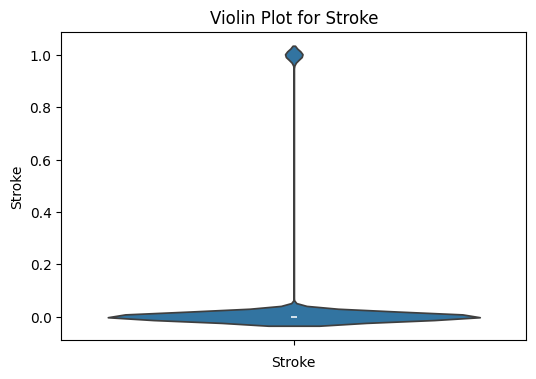

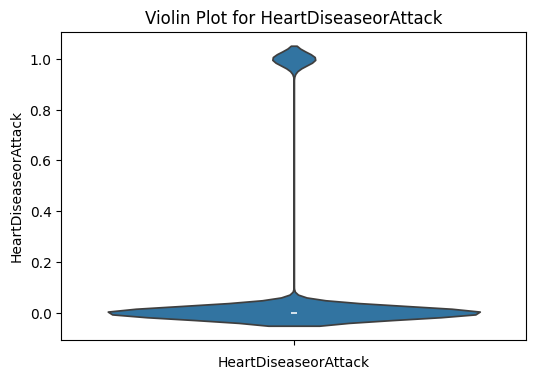

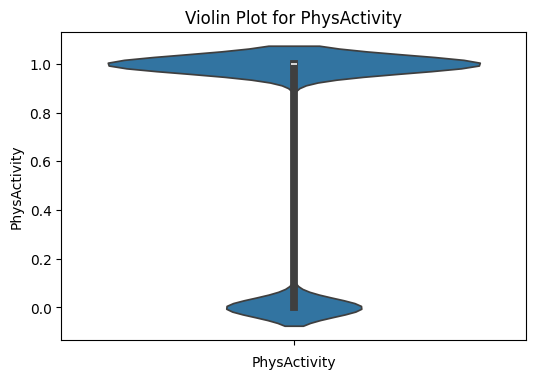

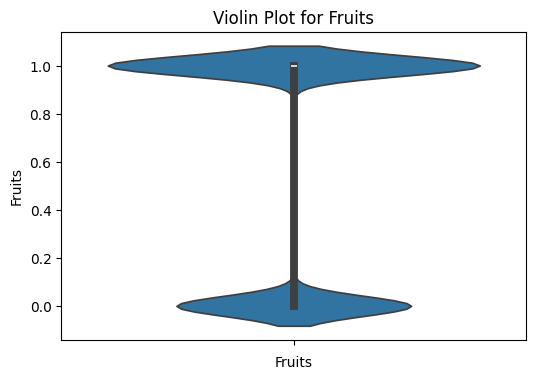

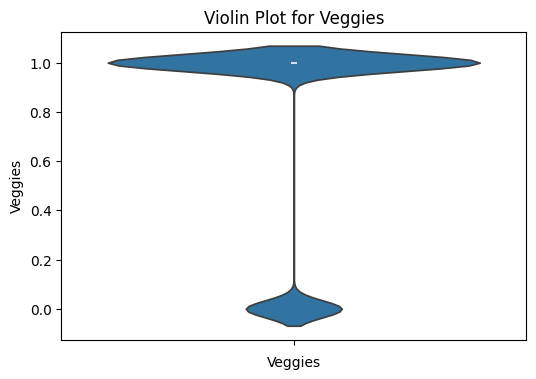

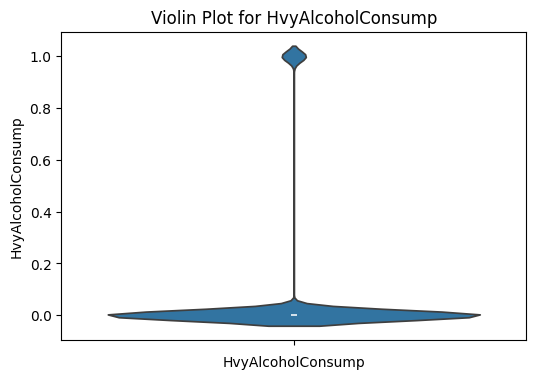

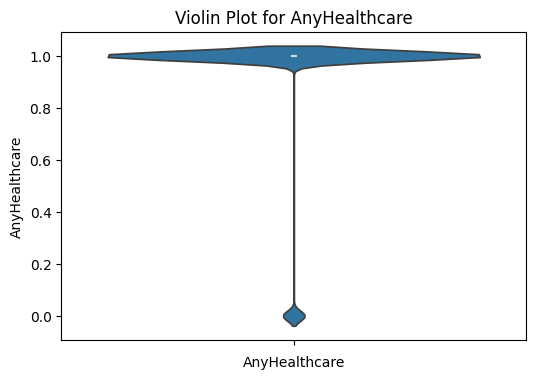

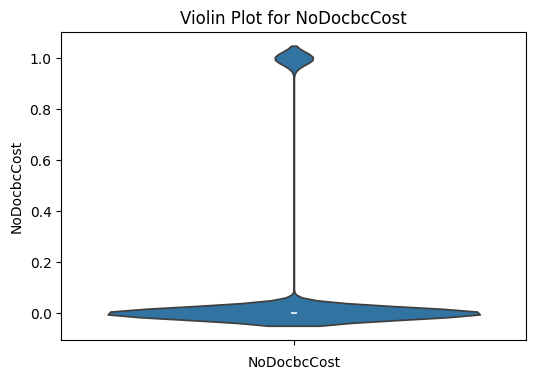

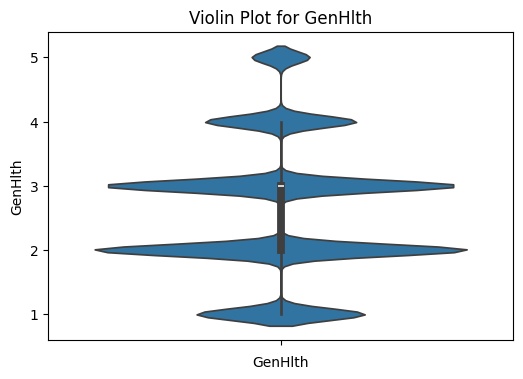

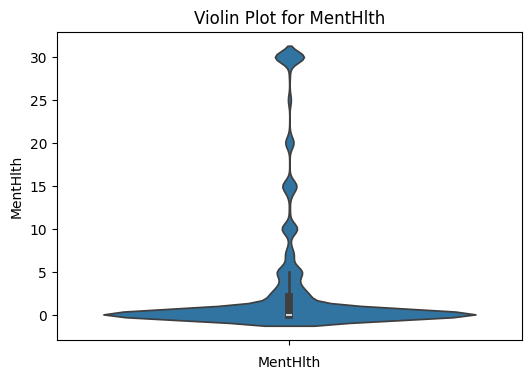

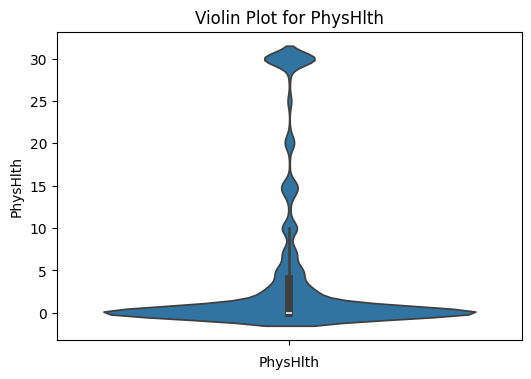

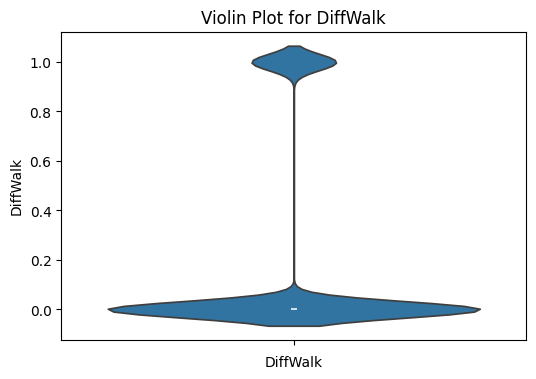

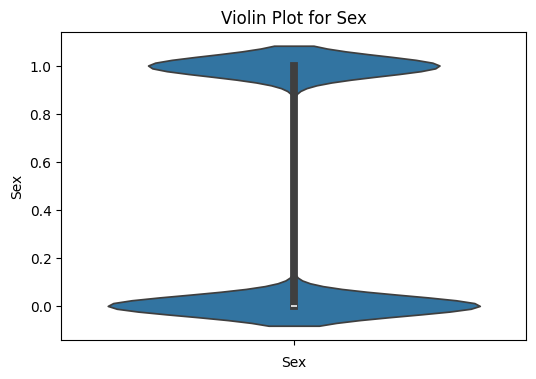

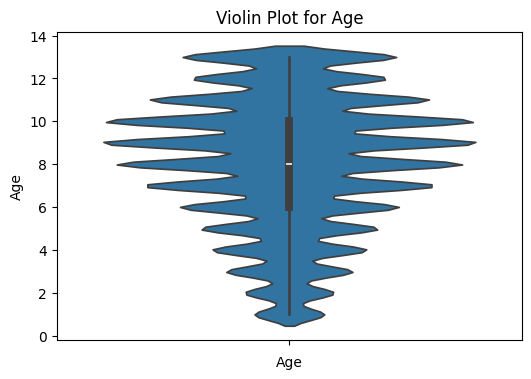

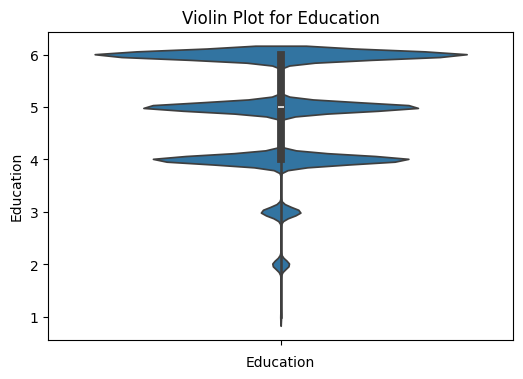

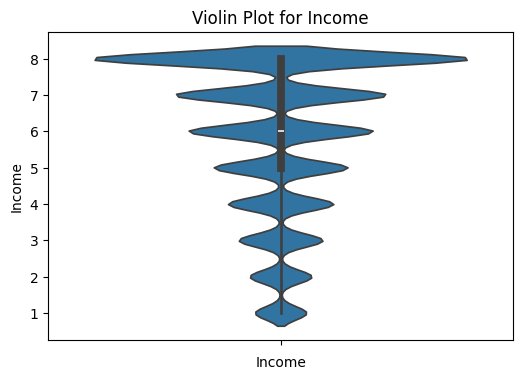

In [11]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.violinplot(data= diabetes_df, y =col, fill=True)
    plt.title(f'Violin Plot for {col}')
    plt.xlabel(col)
    plt.show()

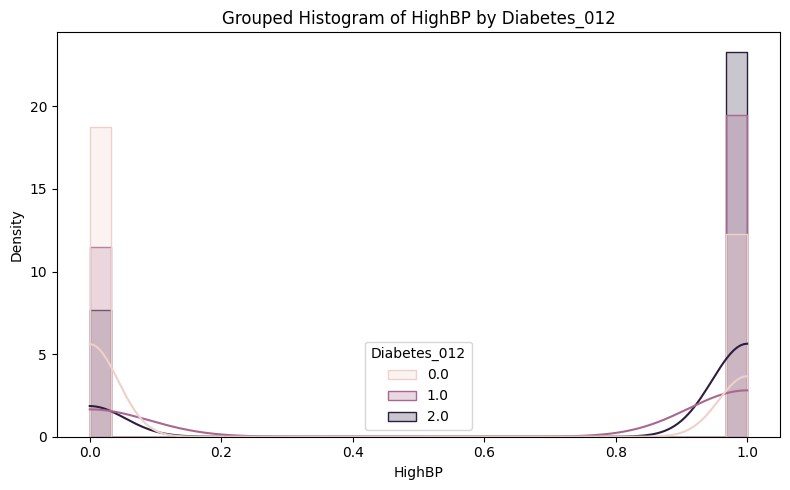

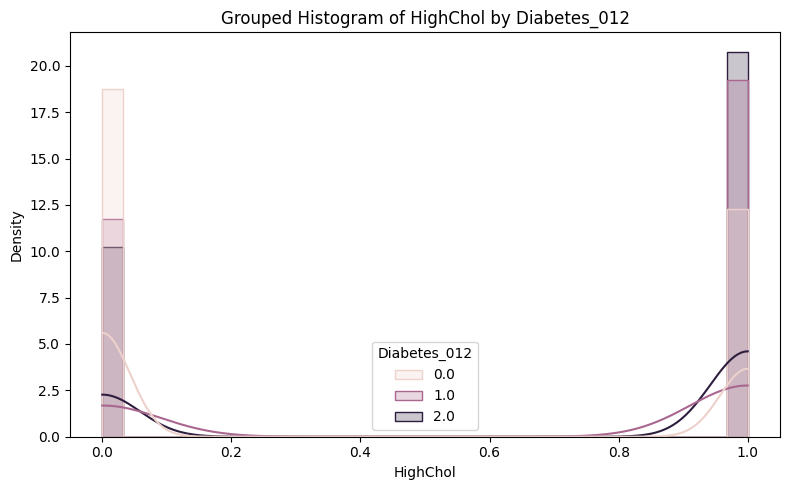

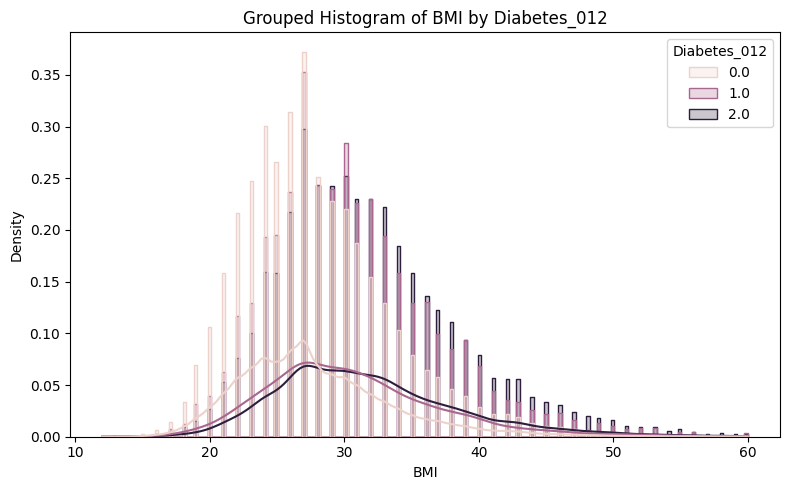

In [12]:
for col in ['HighBP', 'HighChol', 'BMI', 'PhysHealth']:
    if col in diabetes_df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(data=diabetes_df, x=col, hue="Diabetes_012", kde=True, element='step', stat='density', common_norm=False)
        plt.title(f'Grouped Histogram of {col} by {"Diabetes_012"}')
        plt.tight_layout()
        plt.show()

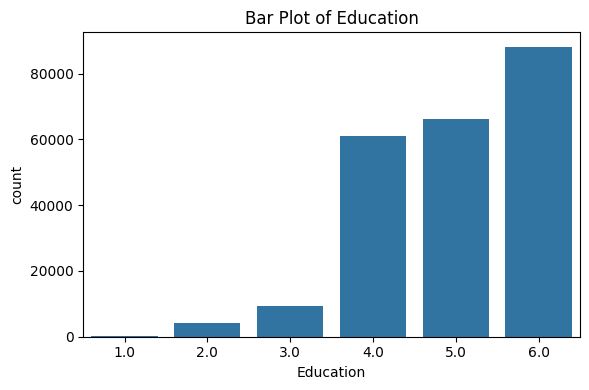

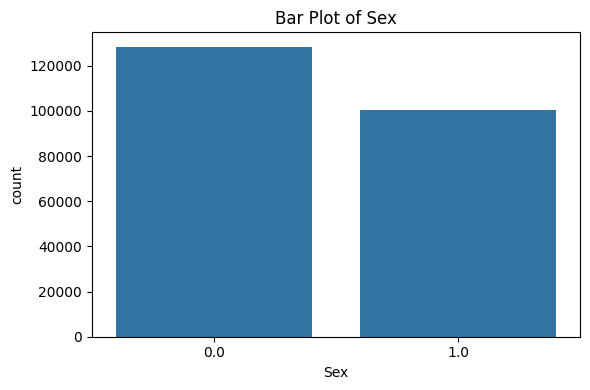

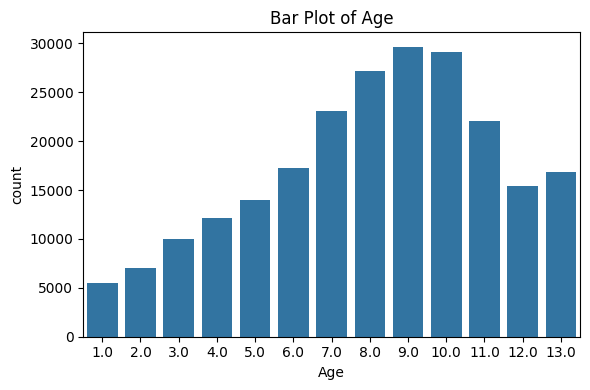

In [13]:
for col in ['Education', 'Sex', 'Age']:
    if col in diabetes_df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=diabetes_df, x=col)
        plt.title(f'Bar Plot of {col}')
        plt.tight_layout()
        plt.show()

In [14]:
mean_values = diabetes_df[numerical_columns].mean()
median_values = diabetes_df[numerical_columns].median()
mode_values = diabetes_df[numerical_columns].mode().iloc[0]

print("Mean:\n", mean_values)
print("\nMedian:\n", median_values)
print("\nMode:\n", mode_values)

Mean:
 Diabetes_012             0.325204
HighBP                   0.454310
HighChol                 0.441889
CholCheck                0.959502
BMI                     28.519351
Smoker                   0.465870
Stroke                   0.044773
HeartDiseaseorAttack     0.103264
PhysActivity             0.733728
Fruits                   0.613217
Veggies                  0.794891
HvyAlcoholConsump        0.060784
AnyHealthcare            0.946134
NoDocbcCost              0.092774
GenHlth                  2.600190
MentHlth                 3.500930
PhysHlth                 4.666834
DiffWalk                 0.184958
Sex                      0.439238
Age                      8.091145
Education                4.980566
Income                   5.891534
dtype: float64

Median:
 Diabetes_012             0.0
HighBP                   0.0
HighChol                 0.0
CholCheck                1.0
BMI                     27.0
Smoker                   0.0
Stroke                   0.0
HeartDiseaseorAtt

### Dataset 2: Census

In [15]:
census_path = kagglehub.dataset_download("muonneutrino/us-census-demographic-data")
print("Path to dataset files:", census_path)

Path to dataset files: /Users/ishita/.cache/kagglehub/datasets/muonneutrino/us-census-demographic-data/versions/3


In [16]:
dataset_path_to_file = os.path.join(census_path, "acs2015_census_tract_data.csv")
census_raw_data = pd.read_csv(dataset_path_to_file)

In [17]:
census_df = census_raw_data.drop_duplicates()

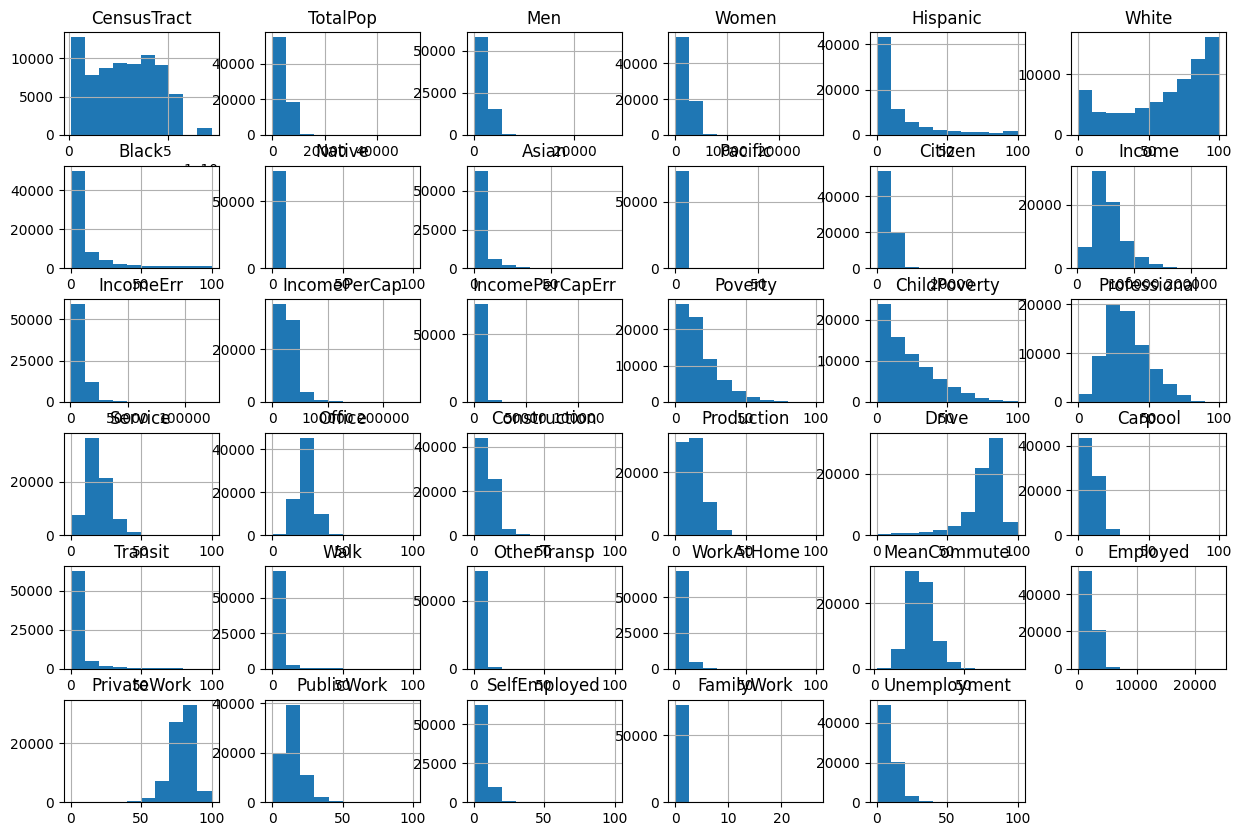

In [18]:
census_df.hist(figsize=(15, 10))
plt.show()

In [20]:

numerical_columns = census_df.select_dtypes(include=['float64', 'int64']).columns
numerical_columns

Index(['CensusTract', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black',
       'Native', 'Asian', 'Pacific', 'Citizen', 'Income', 'IncomeErr',
       'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'ChildPoverty',
       'Professional', 'Service', 'Office', 'Construction', 'Production',
       'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome',
       'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed',
       'FamilyWork', 'Unemployment'],
      dtype='object')

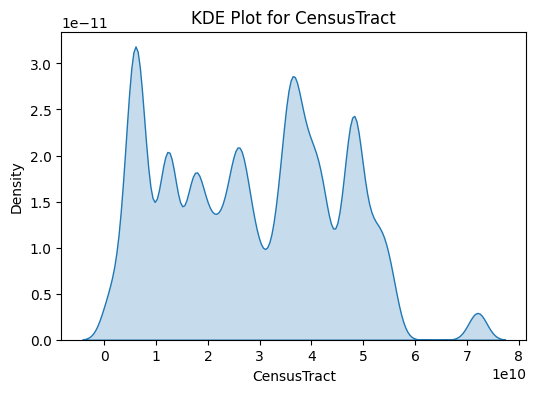

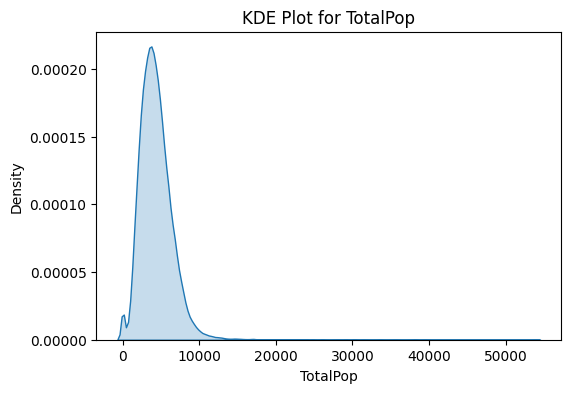

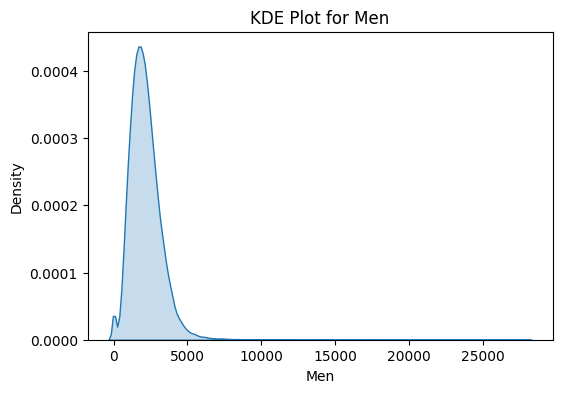

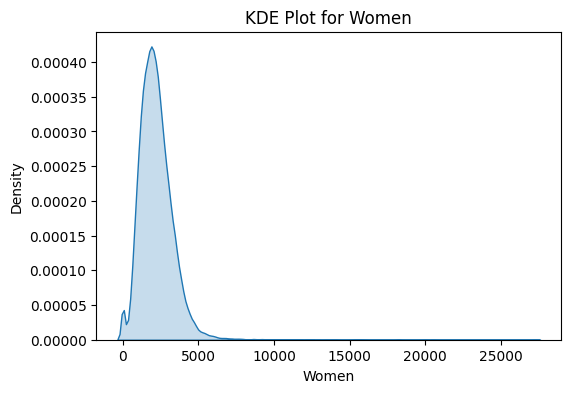

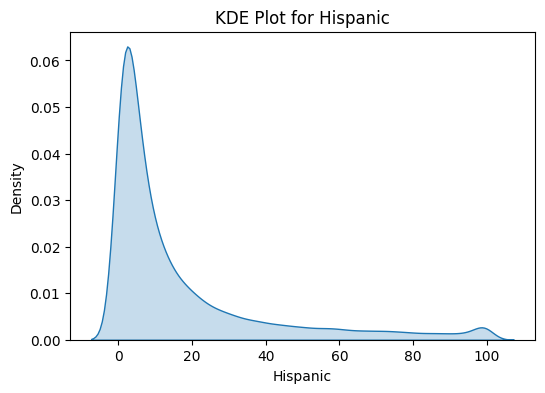

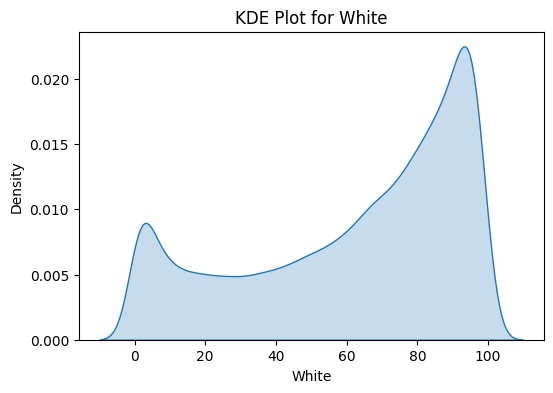

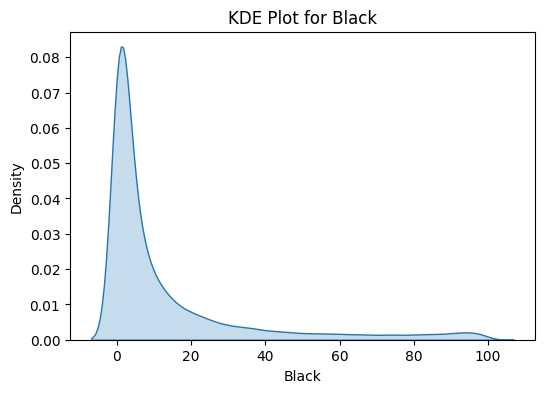

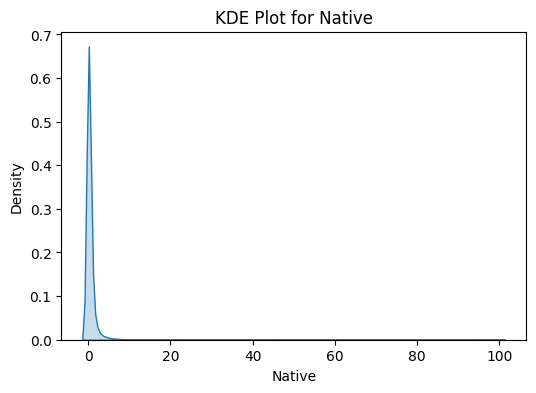

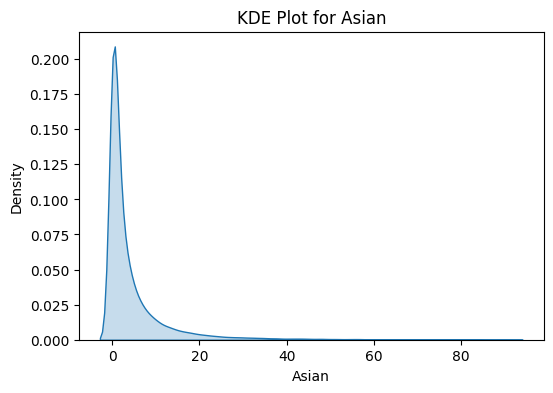

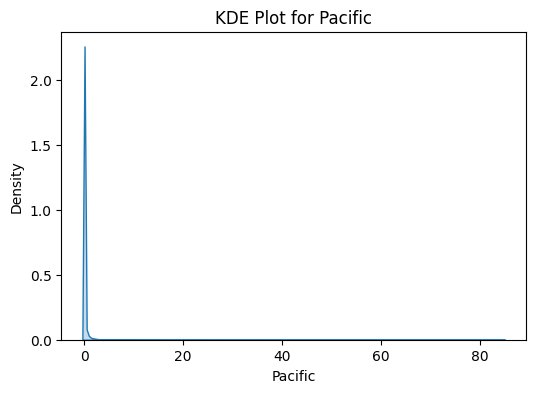

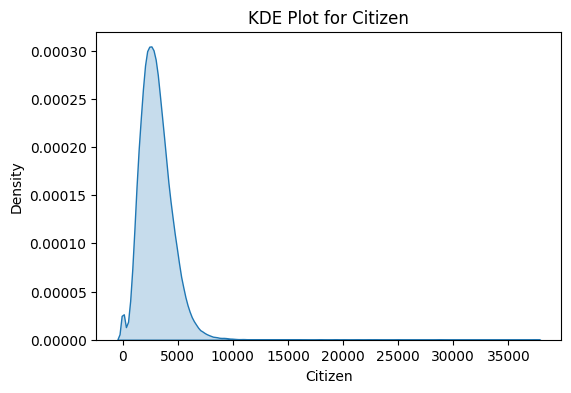

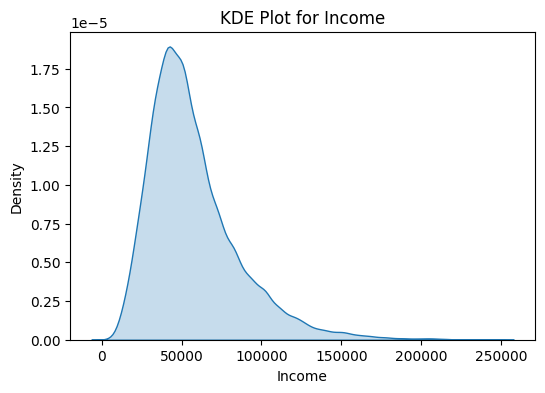

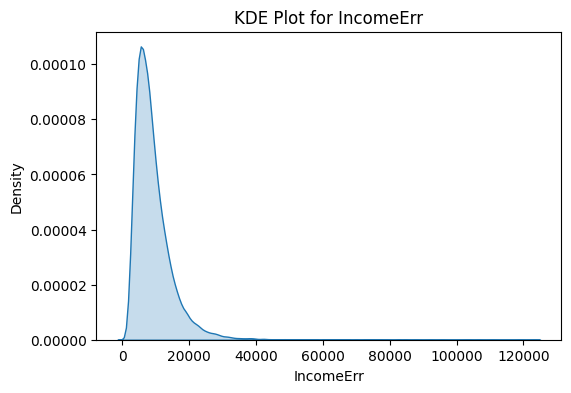

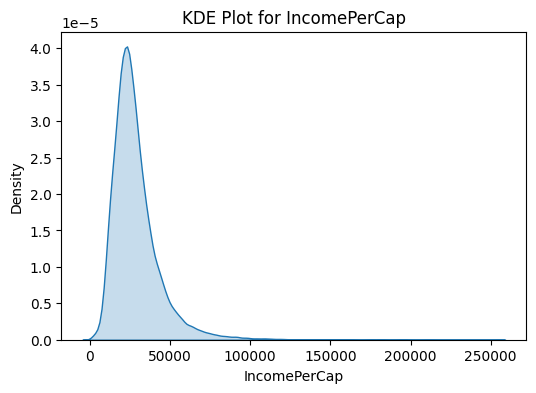

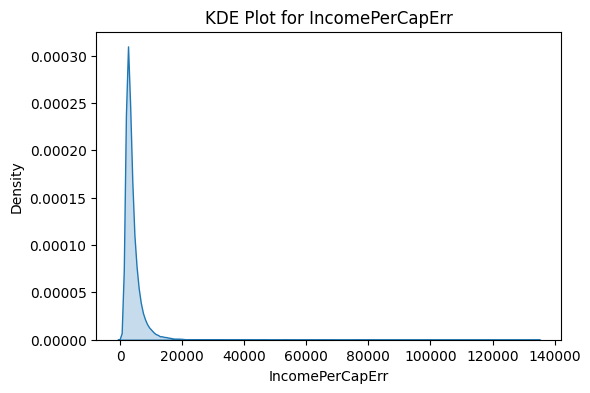

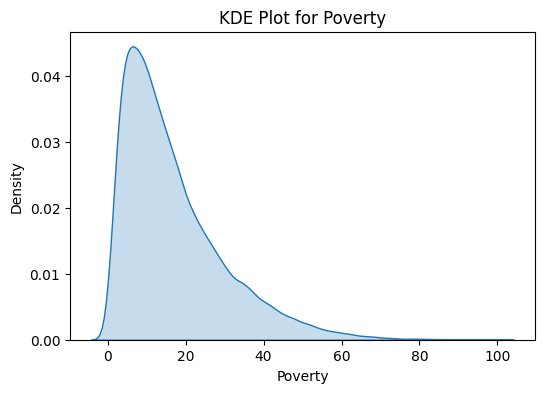

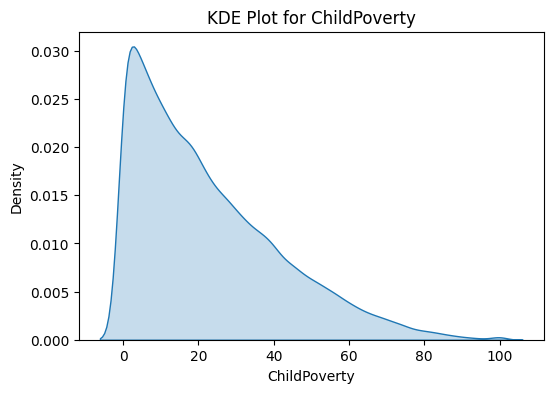

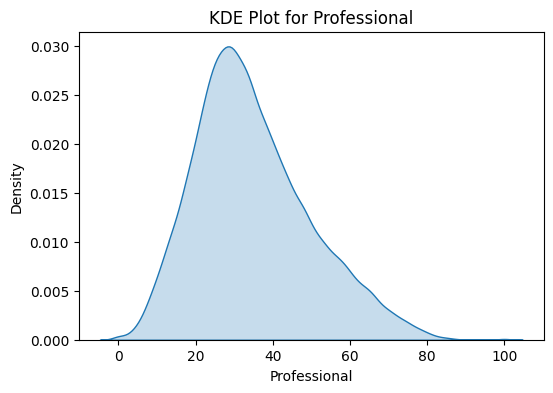

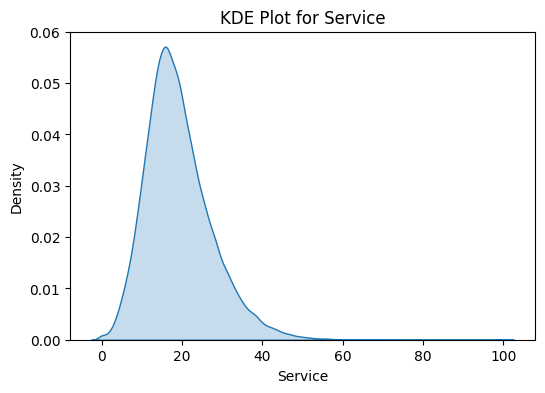

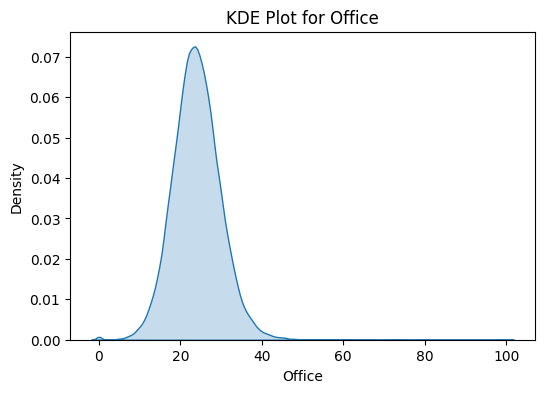

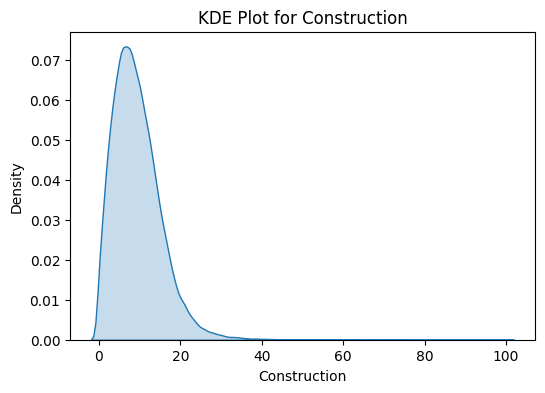

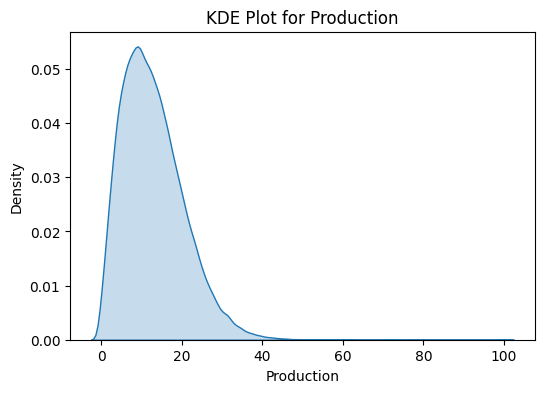

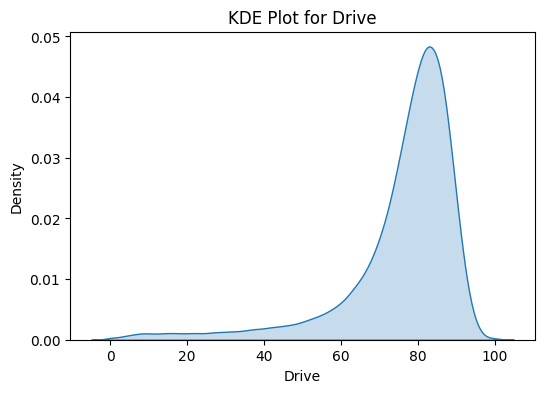

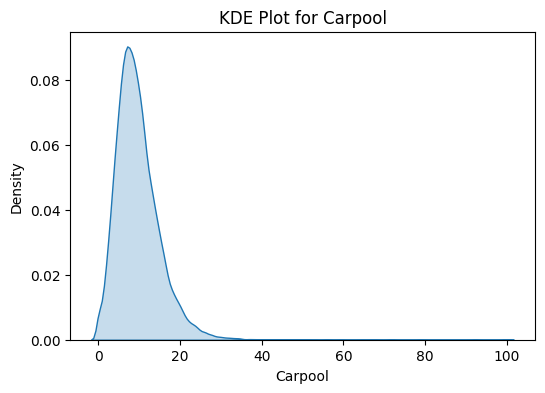

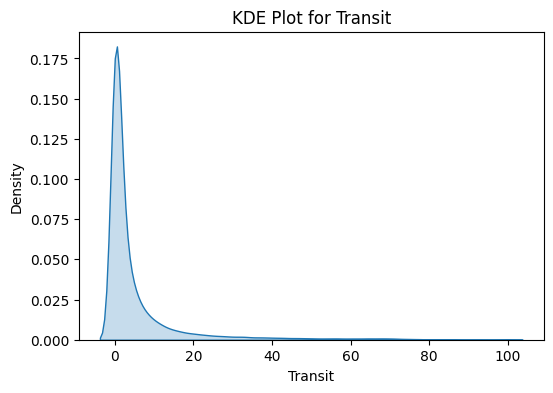

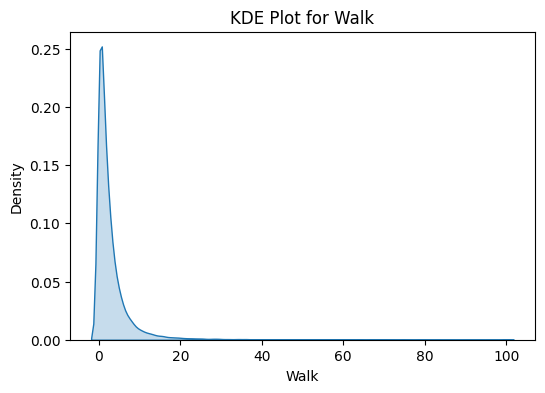

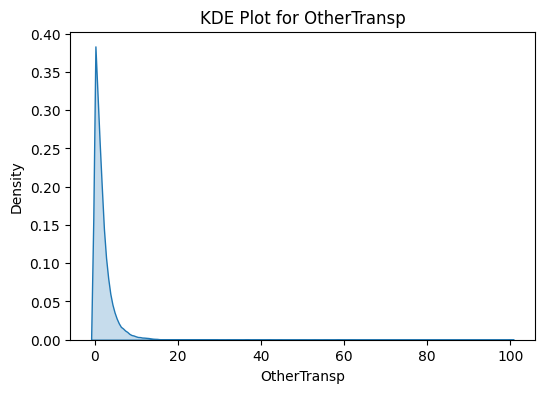

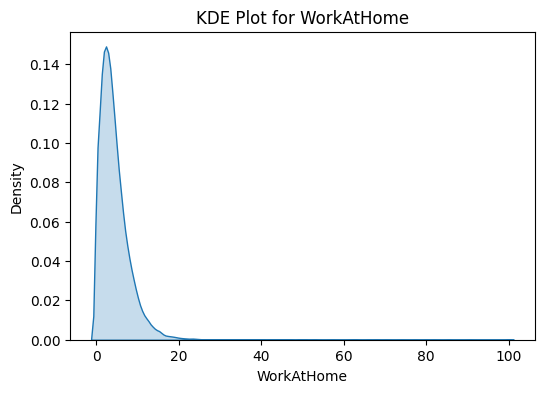

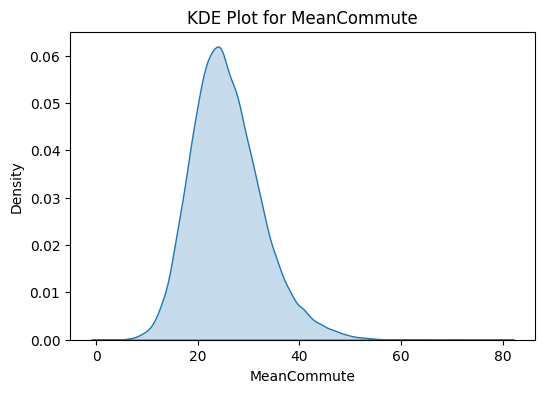

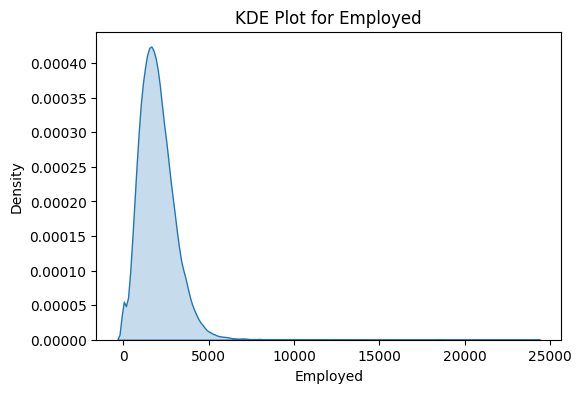

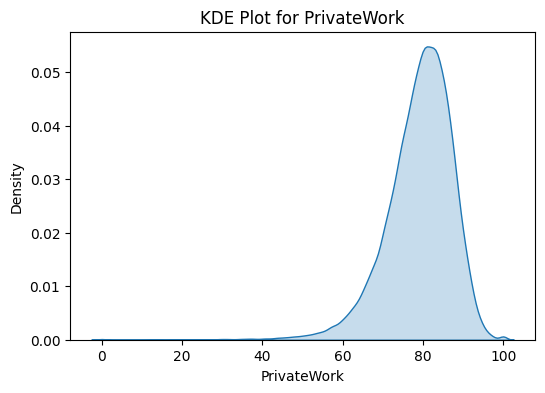

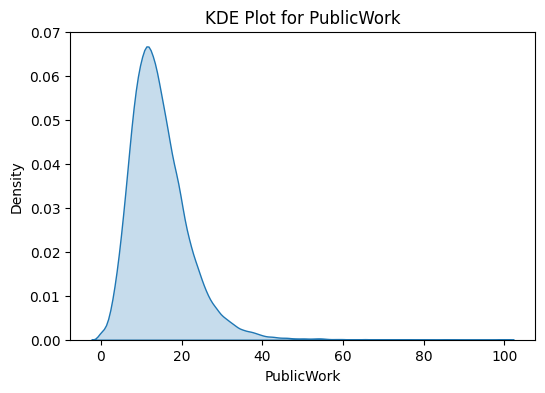

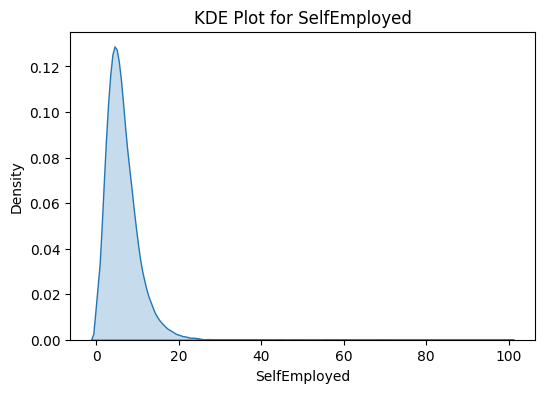

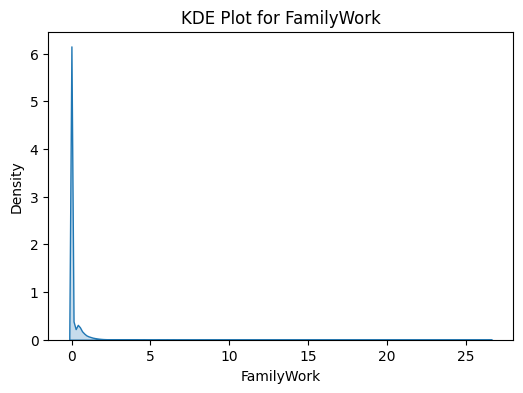

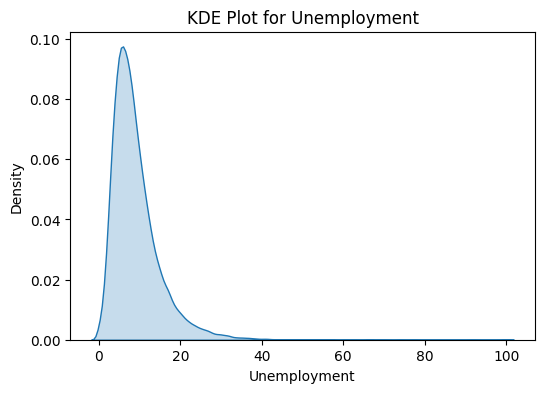

In [22]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=census_df, x=col, fill=True)
    plt.title(f'KDE Plot for {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

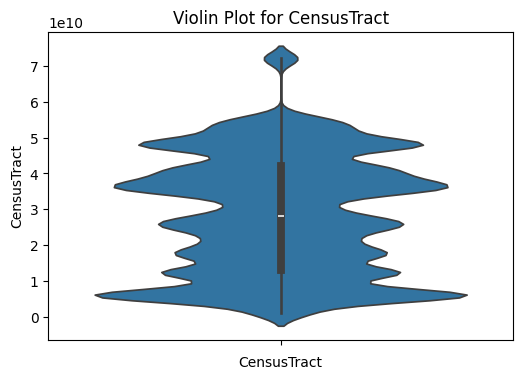

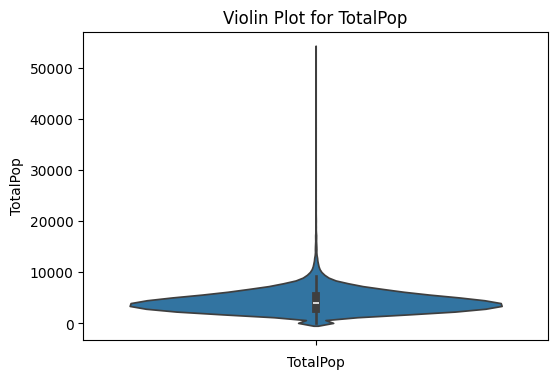

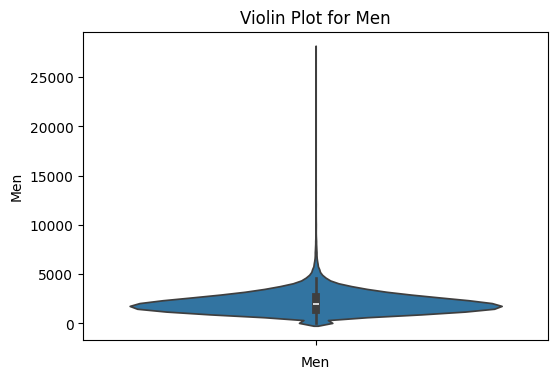

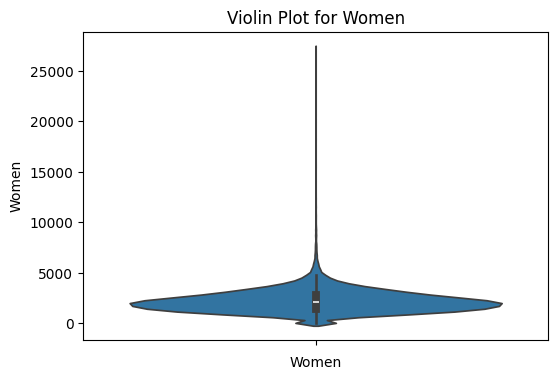

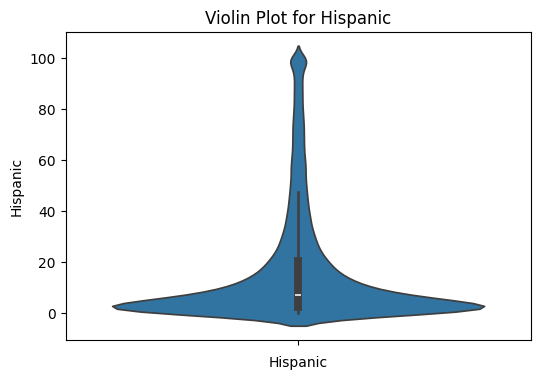

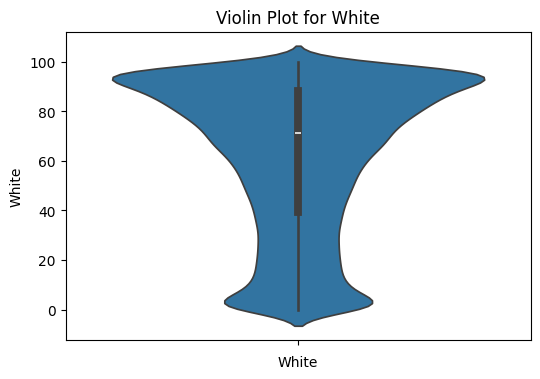

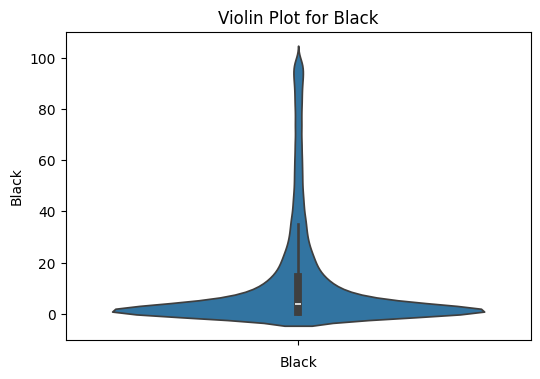

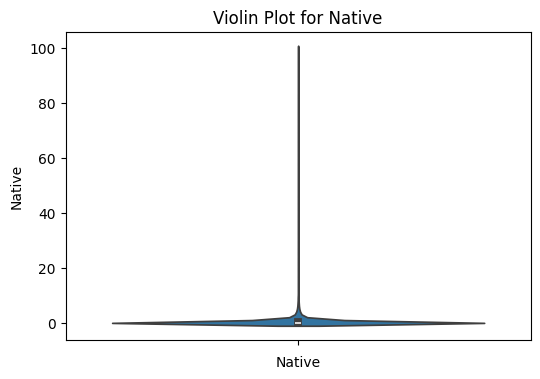

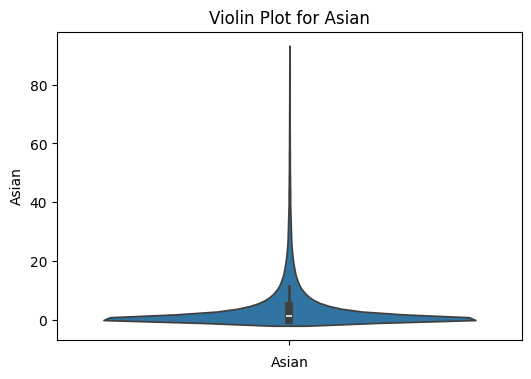

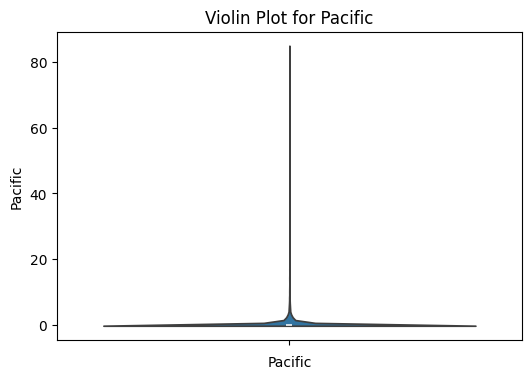

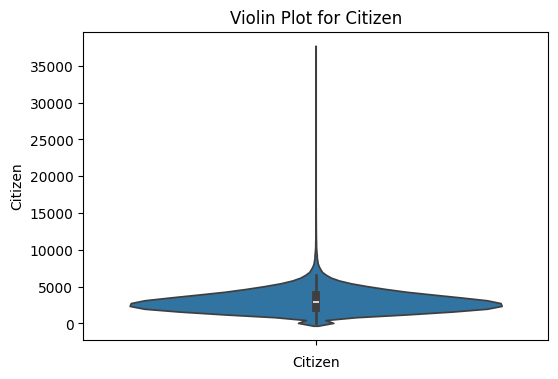

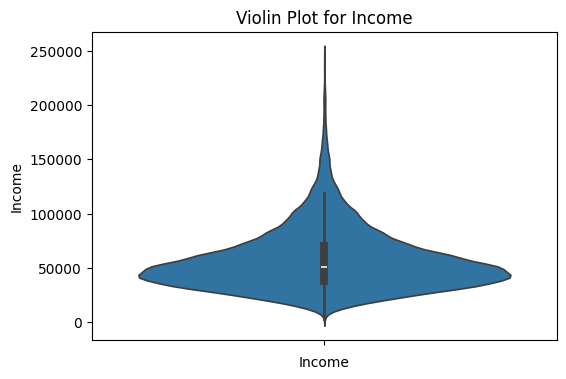

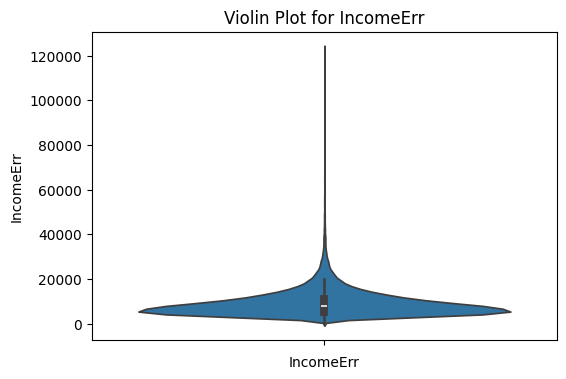

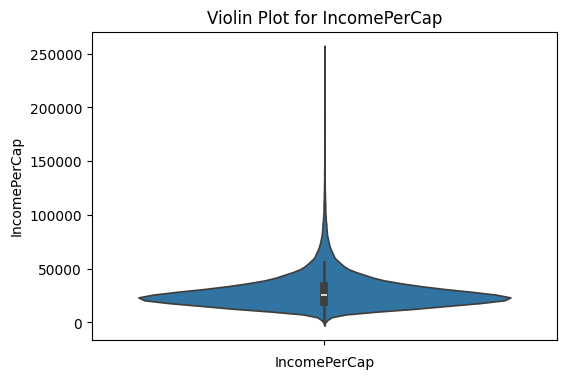

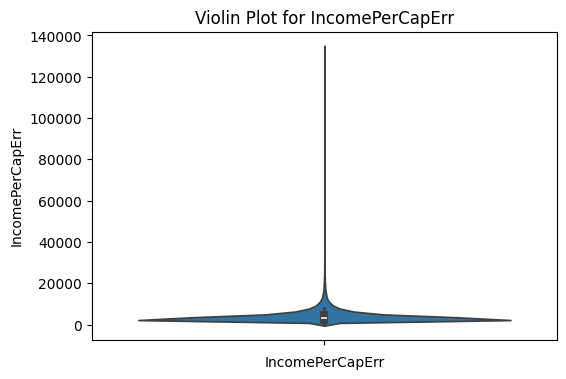

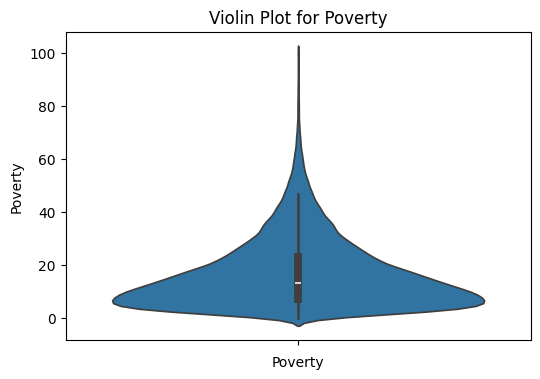

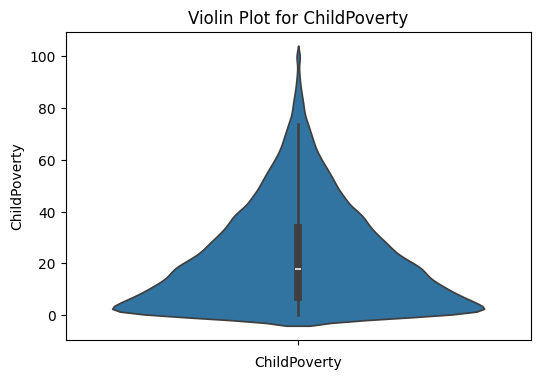

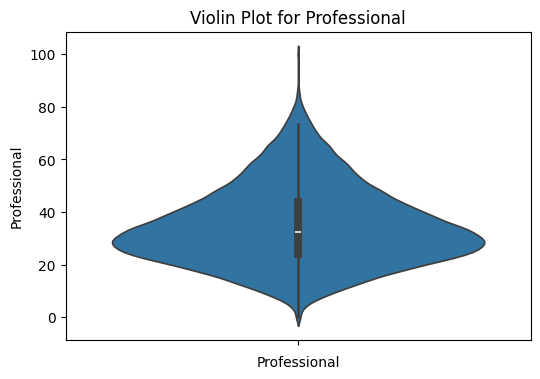

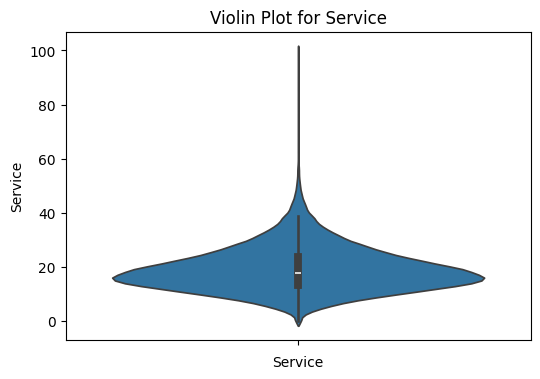

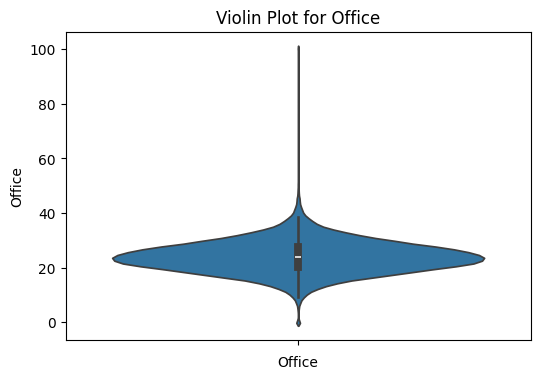

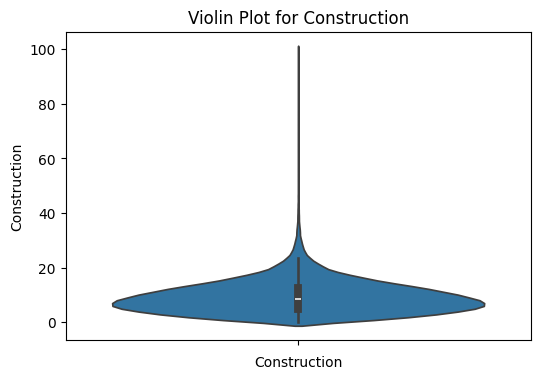

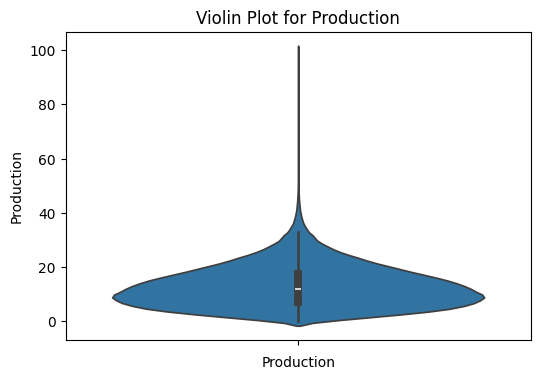

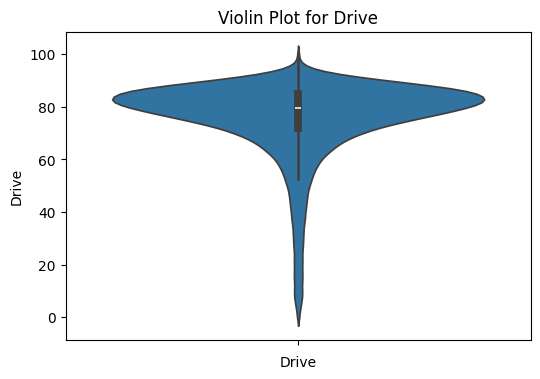

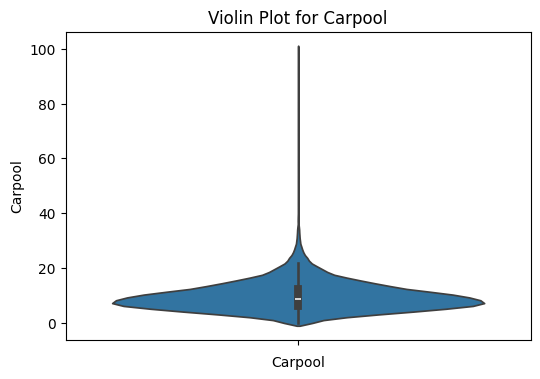

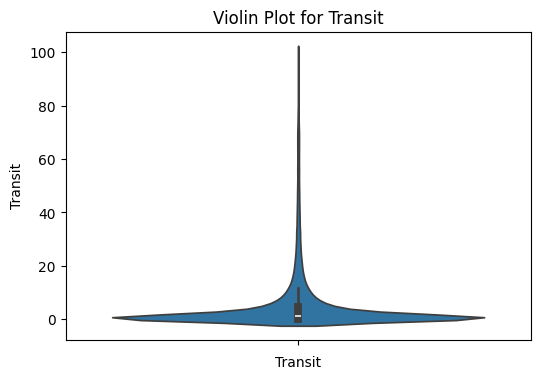

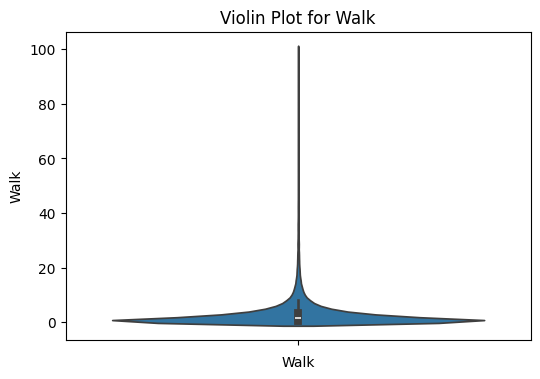

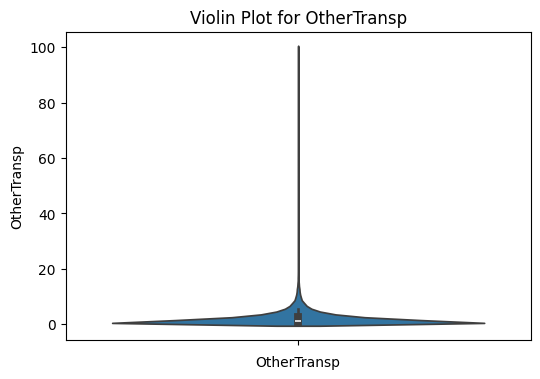

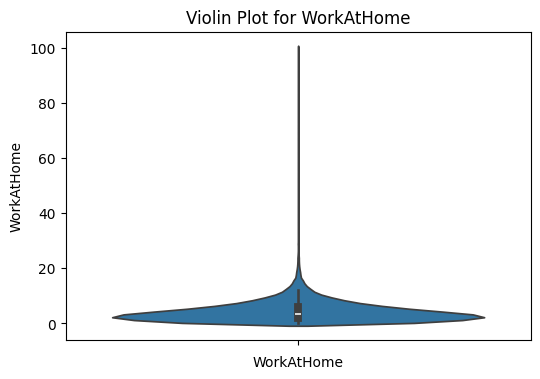

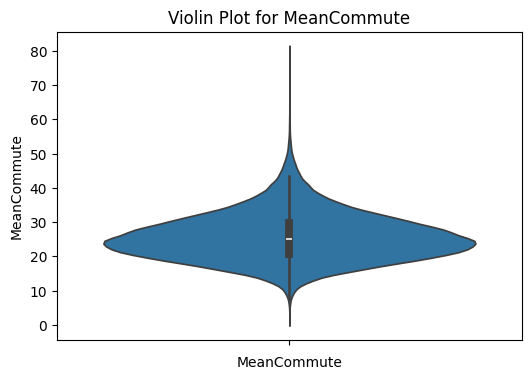

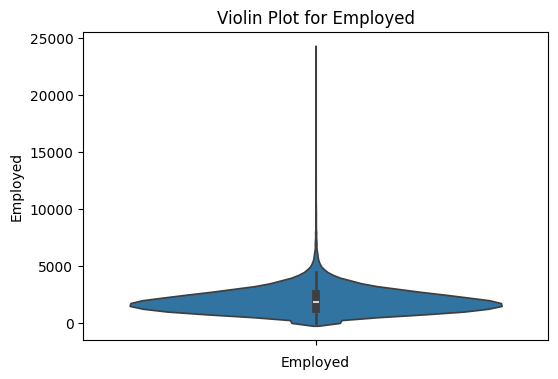

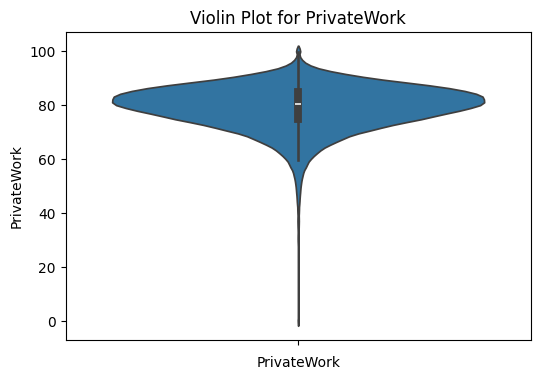

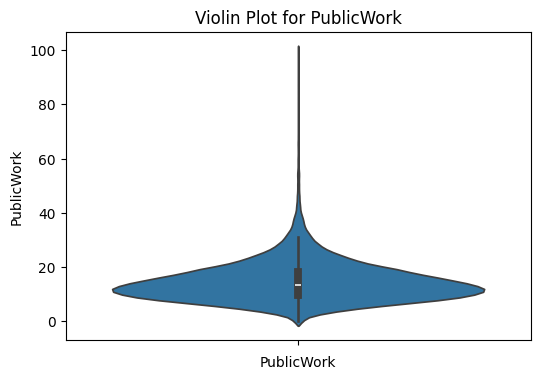

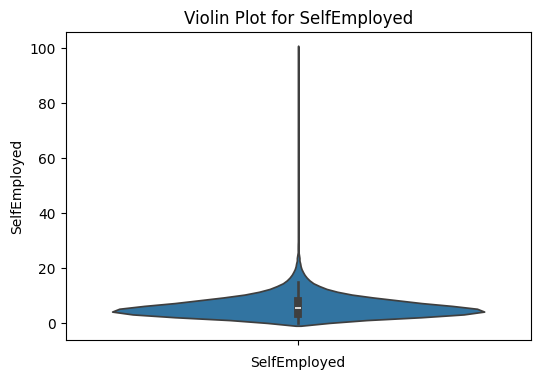

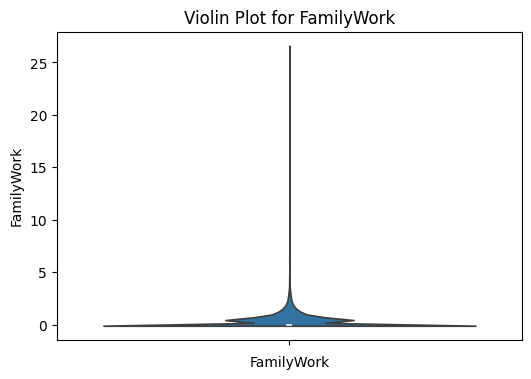

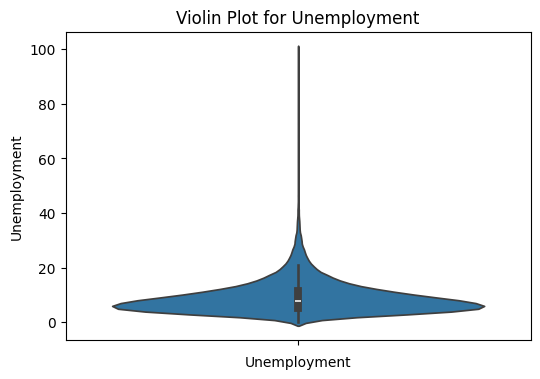

In [23]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.violinplot(data= census_df, y =col, fill=True)
    plt.title(f'Violin Plot for {col}')
    plt.xlabel(col)
    plt.show()

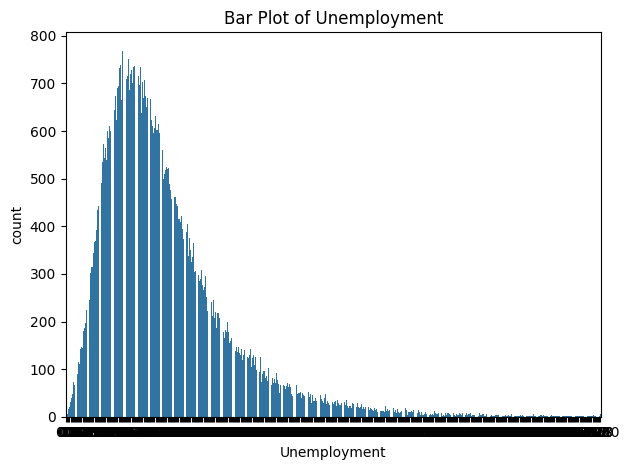

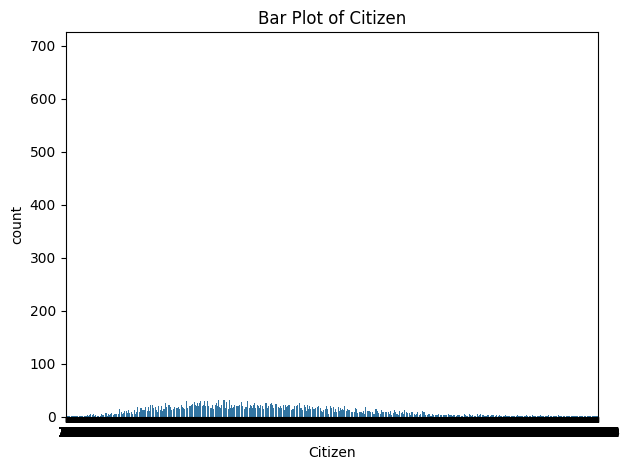

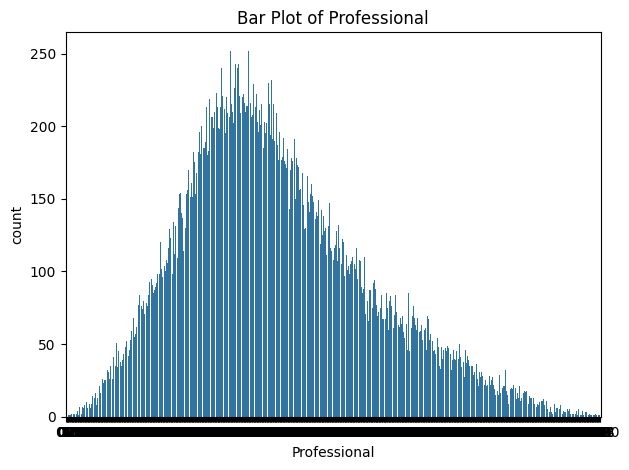

In [ ]:
# Need to figure out how to make x-axis readable
for col in ['Unemployment', 'Citizen', 'Professional']:
    if col in census_df.columns:
        sns.countplot(data=census_df, x=col)
        plt.title(f'Bar Plot of {col}')
        plt.tight_layout()
        plt.show()

### Conclusion

My conclusion is that all the data is usable. 

The hypertension data is right-skewed/uniform. There were some outliers I noticed in BMI and Cholesterol, but overall the data is good.There is higher BMI asssociated with hypertension. Yes, changing the bin width can reduce the noise and give us a general overview, while smaller bin width show more details.

The diabetes data is bimodal. The data distribution is normal, as I did not notice outliers that skewed the data. Since, the data is bimodal, changing the bin width would not have any effect on the data.

The colorectal cancer data is right-skewed/uniform. I did noticed some outliers in Age, but overall the data is good to use. There weren't many obvious trends in these plots. Since majority of the data is uniform, reducing the bid width with reduce the noise, not showing important information.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

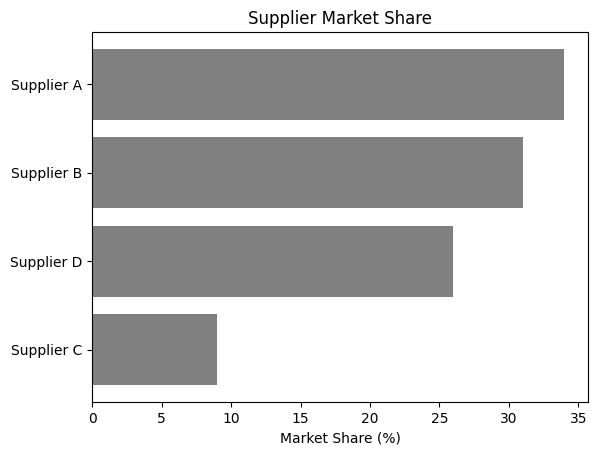

In [ ]:
plt.barh(['Supplier A', 'Supplier B', 'Supplier D', 'Supplier C'], [34, 31, 26, 9], color='gray')
plt.title('Supplier Market Share')
plt.xlabel('Market Share (%)')
plt.gca().invert_yaxis()
plt.show()